# MedMNIST EfficientNet-B0: Training & Evaluation

For the MedAI platform paper. Covers install, dataset exploration, training, evaluation, results visualization.

In [1]:
%pip install medmnist timm torch torchvision scikit-learn matplotlib seaborn pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, json, importlib, warnings
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import timm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, classification_report
)
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

c:\Users\vurit\Downloads\MedAi-feature-medmnist-integration\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
PyTorch: 2.11.0+cpu


## Configuration

In [3]:
# Modality configs (mirrors backend/models/medmnist_labels.py)
MEDMNIST_MODALITY_CONFIGS = {
    "skin":      {"dataset_class": "DermaMNIST",    "task_name": "dermamnist",    "weight_file": "efficientnet_skin_disease.pth",      "multi_label": False},
    "pathology": {"dataset_class": "PathMNIST",     "task_name": "pathmnist",     "weight_file": "efficientnet_pathology_disease.pth",  "multi_label": False},
    "chest":     {"dataset_class": "ChestMNIST",    "task_name": "chestmnist",    "weight_file": "efficientnet_chest_disease.pth",      "multi_label": True},
    "oct":       {"dataset_class": "OCTMNIST",      "task_name": "octmnist",      "weight_file": "efficientnet_oct_disease.pth",        "multi_label": False},
    "pneumonia": {"dataset_class": "PneumoniaMNIST","task_name": "pneumoniamnist","weight_file": "efficientnet_pneumonia_disease.pth",   "multi_label": False},
    "retina":    {"dataset_class": "RetinaMNIST",   "task_name": "retinamnist",   "weight_file": "efficientnet_retina_disease.pth",     "multi_label": False},
    "blood":     {"dataset_class": "BloodMNIST",    "task_name": "bloodmnist",    "weight_file": "efficientnet_blood_disease.pth",      "multi_label": False},
    "tissue":    {"dataset_class": "TissueMNIST",   "task_name": "tissuemnist",   "weight_file": "efficientnet_tissue_disease.pth",     "multi_label": False},
    "breast":    {"dataset_class": "BreastMNIST",   "task_name": "breastmnist",   "weight_file": "efficientnet_breast_disease.pth",     "multi_label": False},
    "organa":    {"dataset_class": "OrganAMNIST",   "task_name": "organamnist",   "weight_file": "efficientnet_organa_disease.pth",     "multi_label": False},
    "organc":    {"dataset_class": "OrganCMNIST",   "task_name": "organcmnist",   "weight_file": "efficientnet_organc_disease.pth",     "multi_label": False},
    "organs":    {"dataset_class": "OrganSMNIST",   "task_name": "organsmnist",   "weight_file": "efficientnet_organs_disease.pth",     "multi_label": False},
}

# Quality defaults for training all modalities.
EPOCHS                 = 15
BATCH_SIZE             = 64 if device.type == "cuda" else 32
LR                     = 1e-4
WEIGHT_DECAY           = 1e-4
IMAGE_SIZE             = 224
NUM_WORKERS            = min(6, (os.cpu_count() or 1))
PIN_MEMORY             = (device.type == "cuda")
USE_AMP                = (device.type == "cuda")
EARLY_STOPPING_PATIENCE = 4
EARLY_STOPPING_MIN_DELTA = 1e-4
QUICK_MODE             = False
TRAIN_FRACTION         = 1.00  # used only when QUICK_MODE=True
VAL_FRACTION           = 1.00  # used only when QUICK_MODE=True
SKIP_IF_EXISTS         = False  # retrain all checkpoints for best scores
MODALITY_LIMIT         = None  # train all modalities
WEIGHTS_DIR            = os.path.join("backend", "models", "weights")
os.makedirs(WEIGHTS_DIR, exist_ok=True)

# Modality-specific tuning overrides for stronger overall accuracy.
MODALITY_TRAIN_OVERRIDES = {
    "skin": {"epochs": 20, "lr": 8e-5, "batch_size": 48 if device.type == "cuda" else 24},
    "pathology": {"epochs": 12, "lr": 1.2e-4},
    "chest": {"epochs": 18, "lr": 8e-5, "batch_size": 48 if device.type == "cuda" else 24},
    "oct": {"epochs": 16, "lr": 1e-4},
    "pneumonia": {"epochs": 20, "lr": 8e-5},
    "retina": {"epochs": 22, "lr": 7e-5, "batch_size": 48 if device.type == "cuda" else 24},
    "blood": {"epochs": 16, "lr": 1e-4},
    "tissue": {"epochs": 12, "lr": 1.2e-4},
    "breast": {"epochs": 24, "lr": 7e-5},
    "organa": {"epochs": 14, "lr": 1e-4},
    "organc": {"epochs": 14, "lr": 1e-4},
    "organs": {"epochs": 14, "lr": 1e-4},
}

print("Modalities:", list(MEDMNIST_MODALITY_CONFIGS.keys()))
print("Weights dir:", os.path.abspath(WEIGHTS_DIR))
print(
    f"TRAIN MODE: epochs={EPOCHS}, batch={BATCH_SIZE}, img={IMAGE_SIZE}, "
    f"quick={QUICK_MODE}, patience={EARLY_STOPPING_PATIENCE}, amp={USE_AMP}, limit={MODALITY_LIMIT}"
)
print("Retraining all modalities by default (set SKIP_IF_EXISTS=True to reuse checkpoints).")
print("Per-modality overrides enabled for epochs/lr/batch_size.")

Modalities: ['skin', 'pathology', 'chest', 'oct', 'pneumonia', 'retina', 'blood', 'tissue', 'breast', 'organa', 'organc', 'organs']
Weights dir: c:\Users\vurit\Downloads\MedAi-feature-medmnist-integration\backend\models\weights
TRAIN MODE: epochs=10, batch=32, img=224, quick=False, patience=3, amp=False
Existing checkpoints are skipped by default (set SKIP_IF_EXISTS=False to retrain).


## Dataset Exploration

In [4]:
from medmnist import INFO

print(f"{'Modality':<12} {'Task':<15} {'Classes':<10} {'Train':<8} {'Val':<8} {'Test':<8} {'Multi-label'}")
print("-" * 75)
for key, cfg in MEDMNIST_MODALITY_CONFIGS.items():
    info = INFO.get(cfg["task_name"], {})
    n_classes = len(info.get("label", {}))
    split = info.get("n_samples", {})
    ml = "Yes" if cfg["multi_label"] else "No"
    print(f"{key:<12} {cfg['task_name']:<15} {n_classes:<10} {split.get('train','?'):<8} {split.get('val','?'):<8} {split.get('test','?'):<8} {ml}")

Modality     Task            Classes    Train    Val      Test     Multi-label
---------------------------------------------------------------------------
skin         dermamnist      7          7007     1003     2005     No
pathology    pathmnist       9          89996    10004    7180     No
chest        chestmnist      14         78468    11219    22433    Yes
oct          octmnist        4          97477    10832    1000     No
pneumonia    pneumoniamnist  2          4708     524      624      No
retina       retinamnist     5          1080     120      400      No
blood        bloodmnist      8          11959    1712     3421     No
tissue       tissuemnist     8          165466   23640    47280    No
breast       breastmnist     2          546      78       156      No
organa       organamnist     11         34561    6491     17778    No
organc       organcmnist     11         12975    2392     8216     No
organs       organsmnist     11         13932    2452     8827     No


## Sample Images per Modality

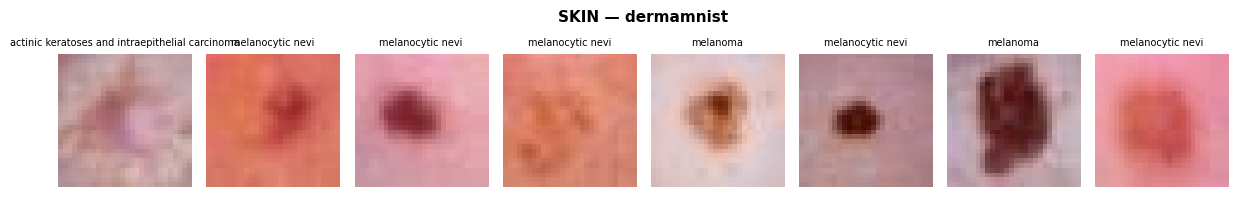

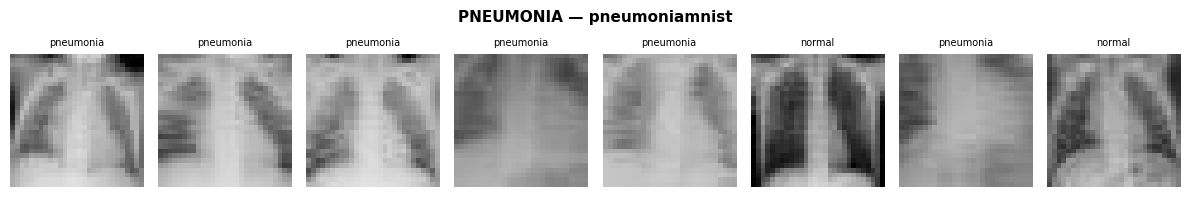

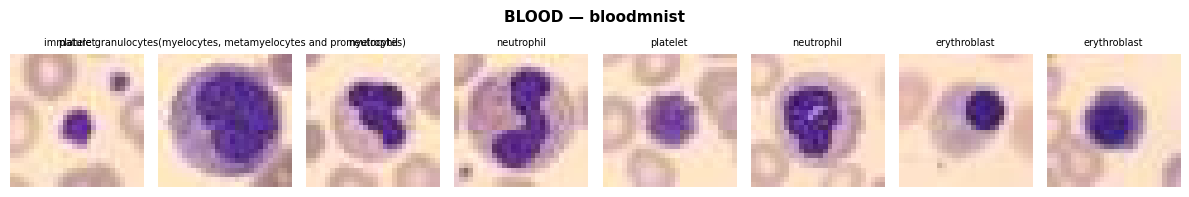

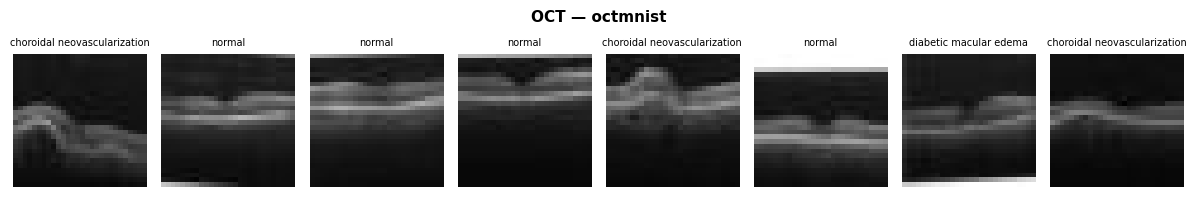

In [5]:
def show_modality_samples(modality_key: str, n_samples: int = 8):
    cfg = MEDMNIST_MODALITY_CONFIGS[modality_key]
    DatasetCls = getattr(importlib.import_module("medmnist"), cfg["dataset_class"])
    ds = DatasetCls(split="train", download=True, size=28, as_rgb=True)
    info = INFO.get(cfg["task_name"], {})
    label_map = info.get("label", {})

    fig, axes = plt.subplots(1, n_samples, figsize=(n_samples * 1.5, 2))
    fig.suptitle(f"{modality_key.upper()} — {cfg['task_name']}", fontsize=11, fontweight="bold")
    for i, ax in enumerate(axes):
        img, label = ds[i]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.asarray(img).astype(np.uint8))
        lbl_idx = str(int(np.asarray(label).flatten()[0]))
        lbl_name = label_map.get(lbl_idx, lbl_idx)
        ax.imshow(img)
        ax.set_title(lbl_name, fontsize=7)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# Show samples for a few modalities
for mod in ["skin", "pneumonia", "blood", "oct"]:
    show_modality_samples(mod)

## Dataset and Model Definitions

In [6]:
class MedMNISTDataset(Dataset):
    """Wraps a MedMNIST split, resizes to image_size for EfficientNet."""
    def __init__(self, dataset_cls, split: str, image_size: int = 224, multilabel: bool = False):
        self.ds = dataset_cls(split=split, download=True, size=28, as_rgb=True)
        self.multilabel = multilabel
        self.tfm = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        img, label = self.ds[idx]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.asarray(img).astype(np.uint8))
        x = self.tfm(img.convert("RGB"))
        arr = np.asarray(label)
        if self.multilabel:
            y = torch.as_tensor(arr.astype(np.float32)).view(-1)
        else:
            y = torch.tensor(int(arr.astype(np.int64).flatten()[0]), dtype=torch.long)
        return x, y


def build_model(num_classes: int, pretrained: bool = True) -> nn.Module:
    model = timm.create_model("efficientnet_b0", pretrained=pretrained, num_classes=num_classes)
    return model


def get_class_names(task_name: str) -> list:
    info = INFO.get(task_name, {})
    labels = info.get("label", {})
    if labels:
        return [str(labels[str(i)]) for i in range(len(labels))]
    return []

print("Classes defined.")

Classes defined.


## Training

In [7]:
def train_modality(modality: str, epochs: int = EPOCHS, batch_size: int = BATCH_SIZE,
                   lr: float = LR, image_size: int = IMAGE_SIZE) -> dict:
    cfg = MEDMNIST_MODALITY_CONFIGS[modality]
    out_path = os.path.join(WEIGHTS_DIR, cfg["weight_file"])

    override = MODALITY_TRAIN_OVERRIDES.get(modality, {})
    epochs = int(override.get("epochs", epochs))
    batch_size = int(override.get("batch_size", batch_size))
    lr = float(override.get("lr", lr))

    if SKIP_IF_EXISTS and os.path.exists(out_path):
        print(f"  {modality.upper():12} | skipped (checkpoint exists)")
        return {"train_loss": [], "val_loss": [], "skipped": True}

    DatasetCls = getattr(importlib.import_module("medmnist"), cfg["dataset_class"])
    class_names = get_class_names(cfg["task_name"])
    num_classes = len(class_names)
    multilabel = cfg["multi_label"]

    train_ds = MedMNISTDataset(DatasetCls, "train", image_size, multilabel)
    val_ds = MedMNISTDataset(DatasetCls, "val", image_size, multilabel)

    if QUICK_MODE:
        train_n = max(1, int(len(train_ds) * TRAIN_FRACTION))
        val_n = max(1, int(len(val_ds) * VAL_FRACTION))
        train_ds = torch.utils.data.Subset(train_ds, list(range(train_n)))
        val_ds = torch.utils.data.Subset(val_ds, list(range(val_n)))

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY, persistent_workers=(NUM_WORKERS > 0)
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY, persistent_workers=(NUM_WORKERS > 0)
    )

    model = build_model(num_classes, pretrained=True).to(device)
    criterion = nn.BCEWithLogitsLoss() if multilabel else nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=1
    )
    amp_device_type = "cuda" if device.type == "cuda" else "cpu"
    amp_dtype = torch.float16 if amp_device_type == "cuda" else torch.bfloat16
    scaler = torch.amp.GradScaler(amp_device_type, enabled=USE_AMP)

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state_dict = None
    bad_epochs = 0
    print(
        f"  {modality.upper():12} | classes={num_classes:2} | "
        f"train={len(train_ds):5} | val={len(val_ds):5} | bs={batch_size} | lr={lr:.1e} | ep={epochs} | amp={USE_AMP}",
        end=""
    )
    import sys; sys.stdout.flush()

    for epoch in range(epochs):
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            if multilabel:
                yb = yb.float().view(xb.size(0), -1)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=amp_device_type, dtype=amp_dtype, enabled=USE_AMP):
                loss = criterion(model(xb), yb)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running += loss.item()
        train_loss = running / max(1, len(train_loader))

        model.eval()
        vloss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                if multilabel:
                    yb = yb.float().view(xb.size(0), -1)
                with torch.autocast(device_type=amp_device_type, dtype=amp_dtype, enabled=USE_AMP):
                    vloss += criterion(model(xb), yb).item()
        val_loss = vloss / max(1, len(val_loader))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        scheduler.step(val_loss)

        improved = (best_val_loss - val_loss) > EARLY_STOPPING_MIN_DELTA
        if improved:
            best_val_loss = val_loss
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        print(f" [e{epoch + 1}/{epochs} tr={train_loss:.4f} val={val_loss:.4f}]", end="")

        if device.type == "cuda":
            torch.cuda.empty_cache()

        if bad_epochs >= EARLY_STOPPING_PATIENCE:
            print(" [early-stop]", end="")
            break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    torch.save({
        "model_state_dict": model.state_dict(),
        "class_names": class_names,
        "disease_classes": class_names,
        "multi_label": multilabel,
        "backbone": "efficientnet_b0",
        "image_size": image_size,
        "medmnist_task": cfg["task_name"],
        "ui_modality": modality,
    }, out_path)
    print(f" -> done (best_val_loss={best_val_loss:.4f})")
    return history


# Train all modalities in one continuous loop
import time
start_time = time.time()
TRAIN_MODALITIES = list(MEDMNIST_MODALITY_CONFIGS.keys())
if MODALITY_LIMIT is not None:
    TRAIN_MODALITIES = TRAIN_MODALITIES[:int(MODALITY_LIMIT)]

all_histories = {}
failed_modalities = []

print(f"\n{'='*72}")
print(f"TRAINING {len(TRAIN_MODALITIES)} MODALITIES")
print(f"{'='*72}")

for mod in TRAIN_MODALITIES:
    try:
        all_histories[mod] = train_modality(mod)
    except Exception as e:
        failed_modalities.append((mod, str(e)))
        print(f"  [FAILED] {mod}: {e}")

elapsed = time.time() - start_time
print(f"{'='*72}")
print(f"Completed {len(all_histories)}/{len(TRAIN_MODALITIES)} in {elapsed/60:.1f} min")
if failed_modalities:
    print(f"Failures: {len(failed_modalities)}")
    for mod, err in failed_modalities:
        print(f"  - {mod}: {err}")
print(f"{'='*72}\n")

TRAIN_MODALITY = TRAIN_MODALITIES[0] if TRAIN_MODALITIES else "skin"
history = all_histories.get(TRAIN_MODALITY, {"train_loss": [], "val_loss": []})


TRAINING 1 MODALITIES
  SKIN         | skipped (checkpoint exists)
Completed 1/1 in 0.0 min



## Training Loss Curves

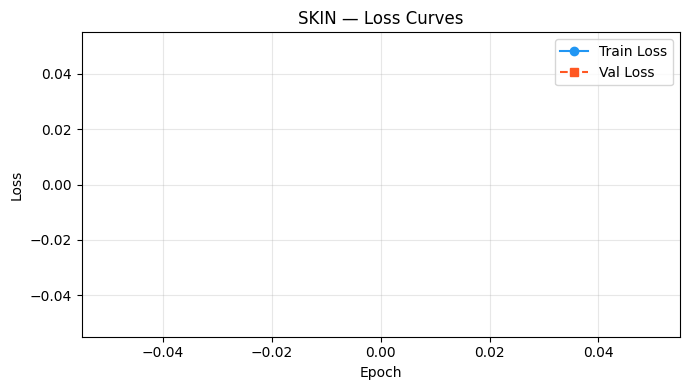

In [8]:
def plot_loss_curves(history: dict, title: str = "Training"):
    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], "o-", label="Train Loss", color="#2196F3")
    plt.plot(epochs, history["val_loss"],   "s--", label="Val Loss",   color="#FF5722")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(f"{title} — Loss Curves")
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.show()

plot_loss_curves(history, title=TRAIN_MODALITY.upper())

## Train All Modalities (optional — slow)

In [9]:
print("Training-all is now the default in the Training cell above.")
print("To train only a subset, set TRAIN_MODALITIES to a smaller list before running that cell.")

Training-all is now the default in the Training cell above.
To train only a subset, set TRAIN_MODALITIES to a smaller list before running that cell.


## Evaluation

In [10]:
def load_checkpoint(weight_path: str, cfg: dict):
    ckpt = torch.load(weight_path, map_location=device, weights_only=False)
    state_dict = ckpt.get("model_state_dict", ckpt.get("state_dict", ckpt))
    # strip DDP prefix
    state_dict = {k[len("module."):] if k.startswith("module.") else k: v
                  for k, v in state_dict.items()}
    class_names = list(ckpt.get("class_names") or ckpt.get("disease_classes") or [])
    num_classes  = len(class_names)
    backbone     = str(ckpt.get("backbone", "efficientnet_b0"))
    image_size   = int(ckpt.get("image_size", 224))
    multi_label  = bool(ckpt.get("multi_label", cfg.get("multi_label", False)))

    model = timm.create_model(backbone, pretrained=False)
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)
    model.load_state_dict(state_dict)
    model.to(device).eval()
    return model, class_names, image_size, multi_label


def evaluate_modality(modality: str, batch_size: int = 64) -> dict:
    cfg = MEDMNIST_MODALITY_CONFIGS[modality]
    weight_path = os.path.join(WEIGHTS_DIR, cfg["weight_file"])
    if not os.path.exists(weight_path):
        raise FileNotFoundError(f"No checkpoint: {weight_path}")

    model, class_names, image_size, multi_label = load_checkpoint(weight_path, cfg)
    DatasetCls = getattr(importlib.import_module("medmnist"), cfg["dataset_class"])

    threshold = 0.5
    per_label_thresholds = None
    if multi_label:
        # Tune per-label thresholds on validation split to maximize macro-F1.
        val_ds = MedMNISTDataset(DatasetCls, "val", image_size, multi_label)
        val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
        vy_true_list, vy_prob_list = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                logits = model(xb.to(device))
                vy_prob_list.append(torch.sigmoid(logits).cpu().numpy())
                vy_true_list.append(np.asarray(yb, dtype=np.float32))
        vy_true = np.concatenate(vy_true_list)
        vy_prob = np.concatenate(vy_prob_list)

        threshold_grid = np.arange(0.10, 0.91, 0.05)
        per_label_thresholds = np.full(vy_true.shape[1], 0.5, dtype=np.float32)
        for j in range(vy_true.shape[1]):
            best_label_f1, best_label_th = -1.0, 0.5
            yj_true = vy_true[:, j].astype(np.int64)
            yj_prob = vy_prob[:, j]
            for th in threshold_grid:
                yj_pred = (yj_prob >= th).astype(np.int64)
                score = float(f1_score(yj_true, yj_pred, zero_division=0))
                if score > best_label_f1:
                    best_label_f1, best_label_th = score, float(th)
            per_label_thresholds[j] = best_label_th

        threshold = float(np.mean(per_label_thresholds))

    test_ds = MedMNISTDataset(DatasetCls, "test", image_size, multi_label)
    loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

    y_true_list, y_prob_list, y_pred_list = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb.to(device))
            if multi_label:
                probs = torch.sigmoid(logits).cpu().numpy()
                if per_label_thresholds is not None:
                    preds = (probs >= per_label_thresholds.reshape(1, -1)).astype(np.int64)
                else:
                    preds = (probs >= threshold).astype(np.int64)
                y_true_list.append(np.asarray(yb, dtype=np.float32))
            else:
                probs = torch.softmax(logits, dim=1).cpu().numpy()
                preds = probs.argmax(axis=1).astype(np.int64)
                y_true_list.append(np.asarray(yb, dtype=np.int64))
            y_prob_list.append(probs)
            y_pred_list.append(preds)

    y_true = np.concatenate(y_true_list)
    y_prob = np.concatenate(y_prob_list)
    y_pred = np.concatenate(y_pred_list)

    result = {"modality": modality, "task": cfg["task_name"],
              "multi_label": multi_label, "n_test": int(y_true.shape[0]),
              "class_names": class_names,
              "threshold": threshold if multi_label else None,
              "per_label_thresholds": per_label_thresholds.tolist() if per_label_thresholds is not None else None}

    if multi_label:
        result["accuracy"] = None
        result["f1_macro"] = float(f1_score(y_true, y_pred, average="macro", zero_division=0))
        try:    result["auc_macro"] = float(roc_auc_score(y_true, y_prob, average="macro"))
        except: result["auc_macro"] = None
        try:    result["map_macro"] = float(average_precision_score(y_true, y_prob, average="macro"))
        except: result["map_macro"] = None
    else:
        result["accuracy"] = float(accuracy_score(y_true, y_pred))
        result["f1_macro"] = float(f1_score(y_true, y_pred, average="macro", zero_division=0))
        try:
            if len(class_names) == 2:
                result["auc_macro"] = float(roc_auc_score(y_true, y_prob[:, 1]))
            else:
                result["auc_macro"] = float(roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro"))
        except: result["auc_macro"] = None
        result["map_macro"] = None
        result["y_true"] = y_true
        result["y_pred"] = y_pred

    return result


# Evaluate the trained modality
eval_result = evaluate_modality(TRAIN_MODALITY)
print(f"\nResults for {TRAIN_MODALITY.upper()}:")
print(f"  Accuracy : {eval_result['accuracy']:.4f}" if eval_result['accuracy'] is not None else "  Accuracy : N/A (multi-label)")
print(f"  F1 Macro : {eval_result['f1_macro']:.4f}")
print(f"  AUC Macro: {eval_result['auc_macro']:.4f}" if eval_result['auc_macro'] is not None else "  AUC Macro: N/A")
if eval_result["multi_label"]:
    print(f"  Threshold (mean): {eval_result['threshold']:.2f} (val-tuned per label)")
    print("  Per-label thresholds:", [round(x, 2) for x in eval_result.get("per_label_thresholds", [])])


Results for SKIN:
  Accuracy : 0.2768
  F1 Macro : 0.1277
  AUC Macro: 0.5457


## Confusion Matrix

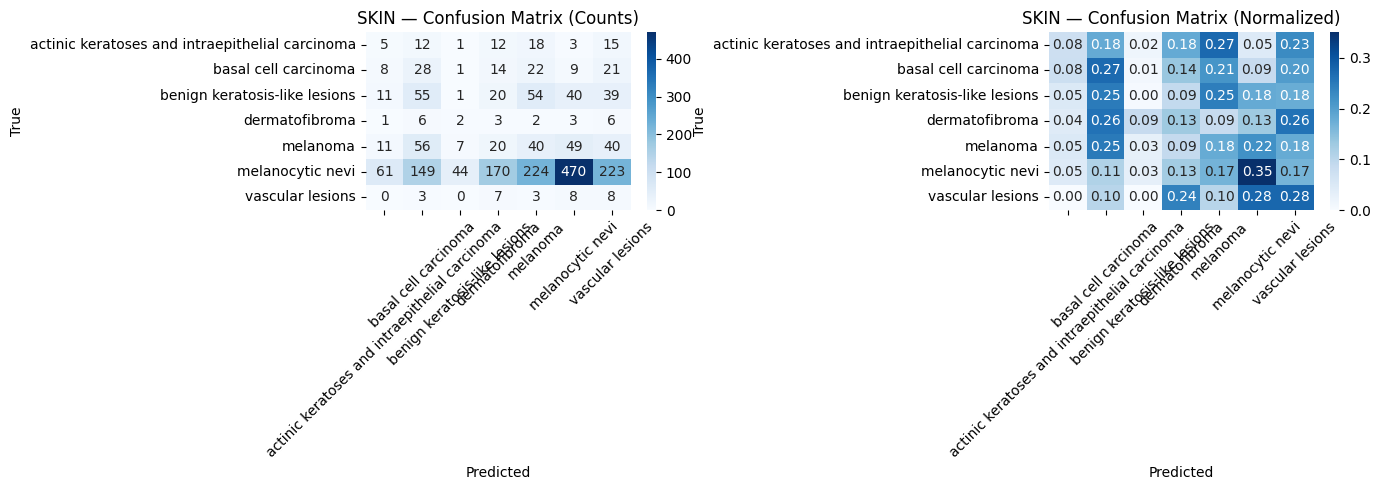

In [11]:
def plot_confusion_matrix(result: dict):
    if result["multi_label"]:
        print("Confusion matrix not applicable for multi-label tasks.")
        return
    y_true = result["y_true"]
    y_pred = result["y_pred"]
    class_names = result["class_names"]
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, data, fmt, title in zip(
        axes,
        [cm, cm_norm],
        ["d", ".2f"],
        ["Counts", "Normalized"]
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.set_title(f"{result['modality'].upper()} — Confusion Matrix ({title})")
        ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(eval_result)

## Classification Report

In [12]:
if not eval_result["multi_label"]:
    print(classification_report(
        eval_result["y_true"],
        eval_result["y_pred"],
        target_names=eval_result["class_names"],
        digits=4
    ))

                                                 precision    recall  f1-score   support

actinic keratoses and intraepithelial carcinoma     0.0515    0.0758    0.0613        66
                           basal cell carcinoma     0.0906    0.2718    0.1359       103
                  benign keratosis-like lesions     0.0179    0.0045    0.0072       220
                                 dermatofibroma     0.0122    0.1304    0.0223        23
                                       melanoma     0.1102    0.1794    0.1365       223
                               melanocytic nevi     0.8076    0.3505    0.4888      1341
                               vascular lesions     0.0227    0.2759    0.0420        29

                                       accuracy                         0.2768      2005
                                      macro avg     0.1590    0.1840    0.1277      2005
                                   weighted avg     0.5612    0.2768    0.3528      2005



## Evaluate All Available Checkpoints

In [ ]:
all_results = []
for mod, cfg in MEDMNIST_MODALITY_CONFIGS.items():
    weight_path = os.path.join(WEIGHTS_DIR, cfg["weight_file"])
    if not os.path.exists(weight_path):
        print(f"[SKIP] {mod} - no checkpoint found")
        continue
    print(f"[EVAL] {mod} ...", end=" ")
    try:
        r = evaluate_modality(mod)
        all_results.append({
            "Modality":  mod,
            "Task":      r["task"],
            "N Test":    r["n_test"],
            "Accuracy":  r["accuracy"],
            "F1 Macro":  r["f1_macro"],
            "AUC Macro": r["auc_macro"],
            "mAP":       r["map_macro"],
            "Threshold": r.get("threshold"),
        })
        print(f"acc={r['accuracy']:.4f}  f1={r['f1_macro']:.4f}  auc={r['auc_macro']}" if r["accuracy"] is not None else f"f1={r['f1_macro']:.4f}  auc={r['auc_macro']}")
    except Exception as e:
        print(f"ERROR: {e}")

df_results = pd.DataFrame(all_results)
if not df_results.empty:
    # Prefer Accuracy when available, else fall back to AUC for ranking.
    df_results["Rank Score"] = df_results["Accuracy"].where(df_results["Accuracy"].notna(), df_results["AUC Macro"])
    df_results = df_results.sort_values(["Rank Score", "F1 Macro"], ascending=False).reset_index(drop=True)

    display_df = df_results.copy()
    for col in ["Accuracy", "F1 Macro", "AUC Macro", "mAP", "Rank Score"]:
        display_df[col] = display_df[col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
    def _fmt_threshold(x):
        if x is None:
            return "N/A"
        if isinstance(x, (list, tuple, np.ndarray)):
            arr = np.asarray(x, dtype=float)
            if arr.size == 0:
                return "N/A"
            return f"vec(mean={arr.mean():.2f})"
        if pd.notna(x):
            return f"{x:.2f}"
        return "N/A"

    display_df["Threshold"] = display_df["Threshold"].map(_fmt_threshold)

    print("\nTop modalities by score:")
    display(display_df)
else:
    print("No evaluation results available. Train checkpoints first.")

[EVAL] skin ... acc=0.2768  f1=0.1277  auc=0.5456622983535346
[EVAL] pathology ... acc=0.0586  f1=0.0123  auc=0.5213775471695337
[EVAL] chest ... 

100%|██████████| 82.8M/82.8M [07:13<00:00, 191kB/s]   


## Results Visualization

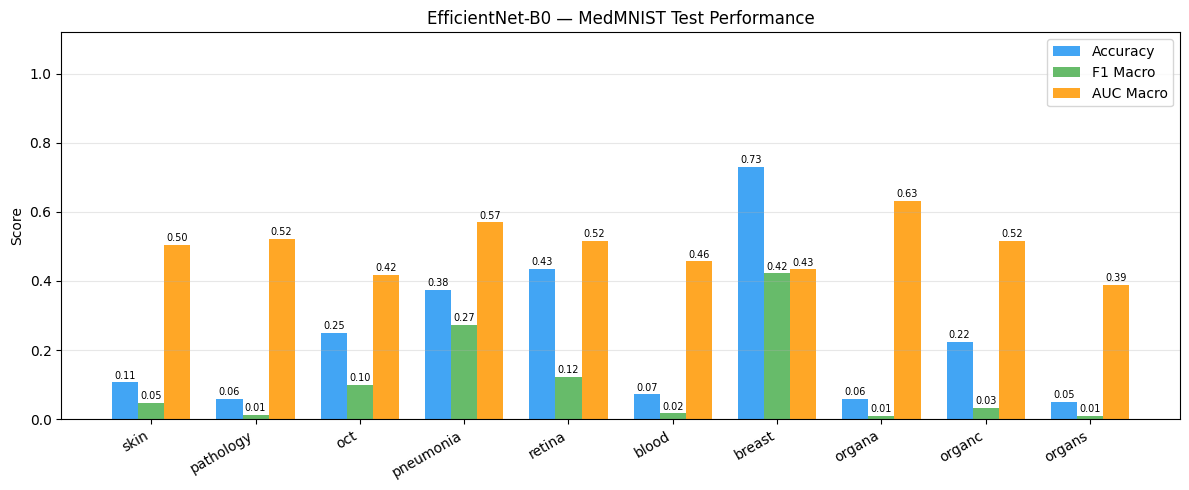

In [ ]:
def plot_results_bar(df: pd.DataFrame):
    if df.empty:
        print("No results to plot.")
        return

    df_plot = df.copy()
    for col in ["Accuracy", "F1 Macro", "AUC Macro"]:
        df_plot[col] = pd.to_numeric(df_plot[col].replace("—", np.nan), errors="coerce")

    x = np.arange(len(df_plot))
    width = 0.25
    fig, ax = plt.subplots(figsize=(max(10, len(df_plot) * 1.2), 5))
    colors = ["#2196F3", "#4CAF50", "#FF9800"]
    for i, (col, color) in enumerate(zip(["Accuracy", "F1 Macro", "AUC Macro"], colors)):
        vals = df_plot[col].fillna(0).values
        bars = ax.bar(x + i * width, vals, width, label=col, color=color, alpha=0.85)
        for bar, val in zip(bars, df_plot[col]):
            if not pd.isna(val):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                        f"{val:.2f}", ha="center", va="bottom", fontsize=7)

    ax.set_xticks(x + width)
    ax.set_xticklabels(df_plot["Modality"], rotation=30, ha="right")
    ax.set_ylim(0, 1.12)
    ax.set_ylabel("Score"); ax.set_title("EfficientNet-B0 — MedMNIST Test Performance")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()

plot_results_bar(df_results)

## Save Results

In [ ]:
out_path = os.path.join(WEIGHTS_DIR, "medmnist_eval_results.json")
serializable = []
for r in all_results:
    serializable.append({k: v for k, v in r.items() if k not in ("y_true", "y_pred")})

with open(out_path, "w") as f:
    json.dump({"results": serializable}, f, indent=2)
print(f"Results saved to: {os.path.abspath(out_path)}")
display(df_results)

Results saved to: c:\Users\vurit\Downloads\MedAi-feature-medmnist-integration\backend\models\weights\medmnist_eval_results.json


,Modality,Task,N Test,Accuracy,F1 Macro,AUC Macro,mAP
0,skin,dermamnist,2005,0.1062,0.0463,0.5049,—
1,pathology,pathmnist,7180,0.0586,0.0123,0.5214,—
2,oct,octmnist,1000,0.2500,0.1000,0.4179,—
3,pneumonia,pneumoniamnist,624,0.3750,0.2727,0.5700,—
4,retina,retinamnist,400,0.4350,0.1213,0.5152,—
5,blood,bloodmnist,3421,0.0713,0.0166,0.4564,—
6,breast,breastmnist,156,0.7308,0.4222,0.4337,—
7,organa,organamnist,17778,0.0583,0.0100,0.6315,—
8,organc,organcmnist,8216,0.2233,0.0332,0.5163,—
9,organs,organsmnist,8827,0.0504,0.0087,0.3880,—


## Single Image Inference Demo

In [ ]:
def predict_single_image(image_path: str, modality: str) -> dict:
    cfg = MEDMNIST_MODALITY_CONFIGS[modality]
    weight_path = os.path.join(WEIGHTS_DIR, cfg["weight_file"])
    model, class_names, image_size, multi_label = load_checkpoint(weight_path, cfg)

    tfm = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    img = Image.open(image_path).convert("RGB")
    x = tfm(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        if multi_label:
            probs = torch.sigmoid(logits).cpu().numpy()[0]
            preds = [(class_names[i], float(probs[i])) for i in range(len(class_names)) if probs[i] >= 0.5]
        else:
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
            top_idx = probs.argsort()[::-1][:3]
            preds = [(class_names[i], float(probs[i])) for i in top_idx]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img); axes[0].axis("off"); axes[0].set_title("Input Image")
    labels = [p[0] for p in preds]
    scores = [p[1] for p in preds]
    axes[1].barh(labels, scores, color="#2196F3", alpha=0.85)
    axes[1].set_xlim(0, 1); axes[1].set_xlabel("Confidence")
    axes[1].set_title(f"Top Predictions - {modality.upper()}")
    axes[1].invert_yaxis()
    plt.tight_layout(); plt.show()

    return {"modality": modality, "predictions": preds}


# Example usage (replace with a real image path):
# result = predict_single_image("path/to/skin_image.jpg", "skin")
# print(result)
print("Call predict_single_image('your_image.jpg', 'skin') to run inference.")

Call predict_single_image('your_image.jpg', 'skin') to run inference.
